# About Dataset
Context
A small subset of dataset of product reviews from Amazon Kindle Store category.

# Content
5-core dataset of product reviews from Amazon Kindle Store category from May 1996 - July 2014. Contains total of 982619 entries. Each reviewer has at least 5 reviews and each product has at least 5 reviews in this dataset.

# Columns
asin - ID of the product, like B000FA64PK

helpful - helpfulness rating of the review - example: 2/3.

overall - rating of the product.

reviewText - text of the review (heading).

reviewTime - time of the review (raw).

reviewerID - ID of the reviewer, like A3SPTOKDG7WBLN

reviewerName - name of the reviewer.

summary - summary of the review (description).

unixReviewTime - unix timestamp.

# Acknowledgements
This dataset is taken from Amazon product data, Julian McAuley, UCSD website. http://jmcauley.ucsd.edu/data/amazon/

License to the data files belong to them.

# Inspiration
Sentiment analysis on reviews.

Understanding how people rate usefulness of a review/ What factors influence helpfulness of are view.

Fake reviews/ outliers.

best rated product IDs, or similarity between products based on reviews alone (not the best idea ikr).

Any other interesting analysis.

# First loading the necessary library and the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
path = r"C:\Users\Public\My projects\notebook\Notebook\Kindle review sentiment analysis\kindle_reviews.csv"
data = pd.read_csv(path)
df = data.copy()
print(f"The head of the dataset:\n{df.head()}")
print("**" * 50)
print(f"The tail of the dataset:\n{df.tail()}")
print("**" * 50)
print(f"The shape of the dataset: {df.shape}")
print("**" * 50)
print(f"The info of the dataset:\n{df.info()}")
print("**" * 50)
print(f"The description of the dataset:\n{df.describe()}")
print("**" * 50)
print(f"The number of missing values in each column:\n{df.isnull().sum()}")
print("**" * 50)

The head of the dataset:
   Unnamed: 0        asin helpful  overall  \
0           0  B000F83SZQ  [0, 0]        5   
1           1  B000F83SZQ  [2, 2]        4   
2           2  B000F83SZQ  [2, 2]        4   
3           3  B000F83SZQ  [1, 1]        5   
4           4  B000F83SZQ  [0, 1]        4   

                                          reviewText   reviewTime  \
0  I enjoy vintage books and movies so I enjoyed ...   05 5, 2014   
1  This book is a reissue of an old one; the auth...   01 6, 2014   
2  This was a fairly interesting read.  It had ol...   04 4, 2014   
3  I'd never read any of the Amy Brewster mysteri...  02 19, 2014   
4  If you like period pieces - clothing, lingo, y...  03 19, 2014   

       reviewerID                         reviewerName             summary  \
0  A1F6404F1VG29J                           Avidreader  Nice vintage story   
1   AN0N05A9LIJEQ                             critters        Different...   
2   A795DMNCJILA6                                

# Now here we only need two columns which is "reviewText" and "rating"

In [3]:
df.columns

Index(['Unnamed: 0', 'asin', 'helpful', 'overall', 'reviewText', 'reviewTime',
       'reviewerID', 'reviewerName', 'summary', 'unixReviewTime'],
      dtype='object')

In [4]:
df.drop(columns=["Unnamed: 0", "reviewerID", "asin", "reviewerName", "helpful", "unixReviewTime", "reviewTime", "summary"], inplace = True)
df.rename(columns={"overall": "rating"}, inplace = True)
df.head()

,rating,reviewText
0,5,I enjoy vintage books and movies so I enjoyed ...
1,4,This book is a reissue of an old one; the auth...
2,4,This was a fairly interesting read. It had ol...
3,5,I'd never read any of the Amy Brewster mysteri...
4,4,"If you like period pieces - clothing, lingo, y..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 982619 entries, 0 to 982618
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   rating      982619 non-null  int64 
 1   reviewText  982597 non-null  object
dtypes: int64(1), object(1)
memory usage: 15.0+ MB


In [6]:
df.shape

(982619, 2)

In [7]:
print(df['rating'].unique())
count = 0
for text in df["reviewText"].unique():
    count += 1
print(f"The number of unique reviews: {count}")

print(type(df["reviewText"].unique()))

[5 4 3 2 1]
The number of unique reviews: 982268
<class 'numpy.ndarray'>


In [8]:
counts =df['rating'].value_counts()
counts

rating
5    575264
4    254013
3     96194
2     34130
1     23018
Name: count, dtype: int64

# Now visualizing the data

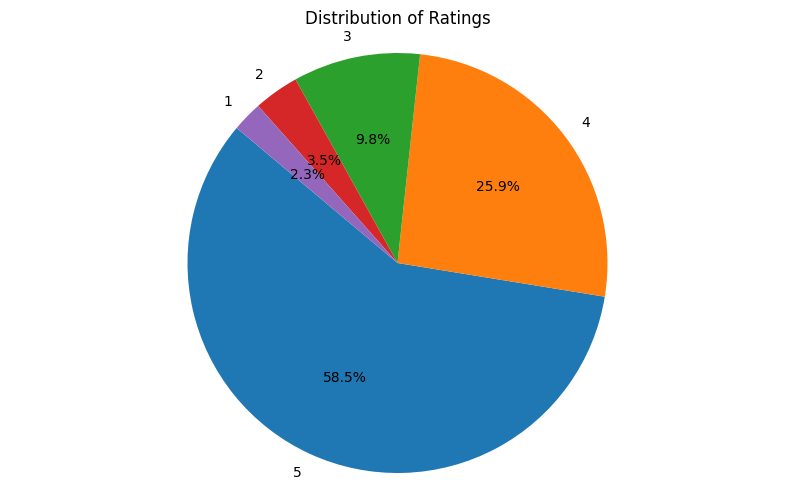

In [9]:
plt.figure(figsize=(10, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Ratings')
plt.axis('equal')
plt.show()

**!HMMM the data is imbalanced for review 1,2 and 3 now I am thinking shall I apply for smote or not may be I will do smote**

In [10]:
df.isnull().sum()

rating         0
reviewText    22
dtype: int64

In [11]:
df.dropna(inplace=True)
df.isnull().sum()

rating        0
reviewText    0
dtype: int64

# Now the preprocessing and cleaning the dataframe

In [12]:
def get_sentiment(rating):
    if rating>3:
        return 0 # Positive
    elif rating == 3:
        return 1 # Neutral
    else:
        return 2 # Negative
df["sentiment"]= df["rating"].map(get_sentiment)
df.head()

,rating,reviewText,sentiment
0,5,I enjoy vintage books and movies so I enjoyed ...,0
1,4,This book is a reissue of an old one; the auth...,0
2,4,This was a fairly interesting read. It had ol...,0
3,5,I'd never read any of the Amy Brewster mysteri...,0
4,4,"If you like period pieces - clothing, lingo, y...",0


In [13]:
df["sentiment"]=df["sentiment"].astype("int32")
df["sentiment"].value_counts()

sentiment
0    829256
1     96193
2     57148
Name: count, dtype: int64

In [14]:
counts =df['sentiment'].value_counts()
counts

sentiment
0    829256
1     96193
2     57148
Name: count, dtype: int64

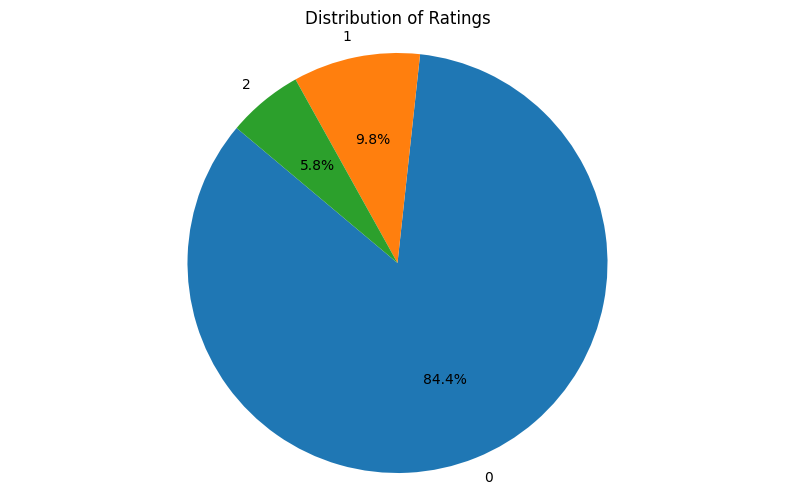

In [15]:
plt.figure(figsize=(10, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Ratings')
plt.axis('equal')
plt.show()

# Now need to do the text review clearning 

**Now importing the necessary libraries**

In [16]:
import nltk
from nltk.corpus import wordnet
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.data.path.append(r'C:\Users\Public\My projects')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import string, re
from nltk import pos_tag
from joblib import Parallel, delayed

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl

In [17]:
! pip install tqdm
from tqdm import tqdm

In [18]:
stop = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Map POS tag to WordNet POS for lemmatization"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [19]:
def process_chunk(text_list):
    """Processes a chunk of text with local caching for speed."""
    chunk_corpus = []
    local_cache = {}  # Stores { 'word': 'lemmatized_word' }

    for doc in text_list:
        if isinstance(doc, list):
            doc = " ".join([str(d).lower() for d in doc])
        elif isinstance(doc, str):
            doc = doc.lower()
        else:
            chunk_corpus.append("")
            continue

        # Clean but keep punctuation for sent_tokenize
        doc = re.sub(r"[^a-zA-Z\s.,!?;:\-]", " ", doc)
        sentences = sent_tokenize(doc)
        
        processed_doc = []
        for sentence in sentences:
            # Tokenize and filter stops
            words = [w for w in word_tokenize(sentence) if w not in stop]
            
            lemmatized_sentence = []
            for w in words:
                # Check if we've seen this word in this chunk already
                if w not in local_cache:
                    tag = pos_tag([w])[0][1]
                    wn_pos = get_wordnet_pos(tag)
                    local_cache[w] = lemmatizer.lemmatize(w, wn_pos)
                
                lemmatized_sentence.append(local_cache[w])
            
            processed_doc.append(" ".join(lemmatized_sentence))
        
        chunk_corpus.append(" ".join(processed_doc))
    
    return chunk_corpus

In [20]:
def fast_sentence_to_lemmatized_sentence(dataframe, column_name, n_jobs=-1):
    # Keep it as a list, NOT a numpy array
    data = dataframe[column_name].astype(str).tolist()
    
    # Manually split the list into chunks without NumPy
    num_chunks = 40
    chunk_size = len(data) // num_chunks
    chunks = [data[i : i + chunk_size] for i in range(0, len(data), chunk_size)]
    
    print(f"Starting processing {len(data)} rows in {len(chunks)} chunks...")
    
    # Use tqdm to track progress
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_chunk)(c) for c in tqdm(chunks, desc="Processing Chunks")
    )
    
    # Flatten results back into a single list
    return [item for sublist in results for item in sublist]

In [21]:
corpus = fast_sentence_to_lemmatized_sentence(df, "reviewText")

Starting processing 982597 rows in 41 chunks...


Processing Chunks: 100%|██████████| 41/41 [00:51<00:00,  1.26s/it]


In [22]:
df["processed_review"] = corpus

In [23]:
df.head()

,rating,reviewText,sentiment,processed_review
0,5,I enjoy vintage books and movies so I enjoyed ...,0,enjoy vintage book movie enjoy reading book . ...
1,4,This book is a reissue of an old one; the auth...,0,"book reissue old one ; author born . era , say..."
2,4,This was a fairly interesting read. It had ol...,0,fairly interest read . old- style terminology....
3,5,I'd never read any of the Amy Brewster mysteri...,0,never read amy brewster mystery one .. really ...
4,4,"If you like period pieces - clothing, lingo, y...",0,"like period piece - clothing , lingo , enjoy m..."


# Now again dropping the rating an raw review text

In [24]:
df.drop(columns=["reviewText","rating"], inplace=True)
df.head()

,sentiment,processed_review
0,0,enjoy vintage book movie enjoy reading book . ...
1,0,"book reissue old one ; author born . era , say..."
2,0,fairly interest read . old- style terminology....
3,0,never read amy brewster mystery one .. really ...
4,0,"like period piece - clothing , lingo , enjoy m..."


In [25]:
df["sentiment"].value_counts()

sentiment
0    829256
1     96193
2     57148
Name: count, dtype: int64

In [26]:
df.isnull().sum()

sentiment           0
processed_review    0
dtype: int64

# Now declaring the independant(input) and dependant(output) variable

In [27]:
X = df["processed_review"]
y = df["sentiment"]

In [28]:
X.shape, y.shape

((982597,), (982597,))

# Now comes the train_test_split 

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [30]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((687817,), (687817,), (294780,), (294780,))

In [31]:
type(X_train), type(y_train)

(pandas.core.series.Series, pandas.core.series.Series)

# Now need to do the vectorization using tfidf

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,3))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [33]:
print(vectorizer.get_feature_names_out()[:100])

['aaron' 'abandon' 'abandonment' 'abbey' 'abbi' 'abby' 'abduct'
 'abduction' 'abe' 'abel' 'abigail' 'ability' 'ability make'
 'ability write' 'able' 'able connect' 'able find' 'able finish'
 'able follow' 'able get' 'able give' 'able handle' 'able help'
 'able keep' 'able make' 'able move' 'able overcome' 'able put'
 'able put book' 'able read' 'able relate' 'able see' 'able stop'
 'able take' 'able write' 'aboard' 'abound' 'about' 'abrupt' 'abrupt end'
 'abruptly' 'absence' 'absent' 'absolute' 'absolute favorite' 'absolutely'
 'absolutely adore' 'absolutely amaze' 'absolutely love'
 'absolutely love book' 'absolutely love series' 'absolutely love story'
 'absolutely nothing' 'absolutely perfect' 'absolutely recommend'
 'absolutely wonderful' 'absorb' 'absorbed' 'absurd' 'abundance' 'abuse'
 'abuser' 'abusive' 'abusive relationship' 'academic' 'academy' 'accent'
 'accept' 'acceptable' 'acceptance' 'accepted' 'accepts' 'access'
 'accessible' 'accident' 'accidental' 'accidentally' 'accom

# Now I need to do the under sampling making the data little bit balanced

In [34]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42, sampling_strategy="not minority")
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_tfidf, y_train)
print(f"Original training size: {X_train_tfidf.shape[0]}")
print(f"Balanced training size: {X_train_resampled.shape[0]}")

Original training size: 687817
Balanced training size: 120012


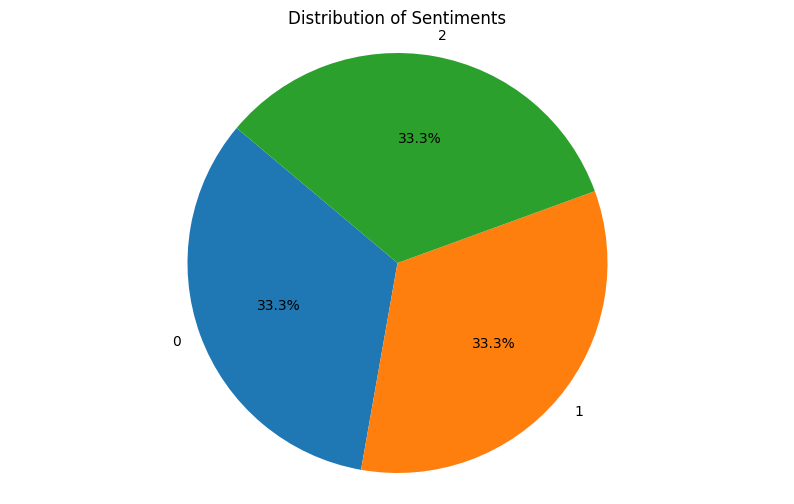

In [35]:
counts = y_train_resampled.value_counts()
plt.figure(figsize=(10, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Sentiments')
plt.axis('equal')
plt.show()

**WOw That is an impressive balancing I did**

# Now making a custom fuction for evalution and traing of each model

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              AdaBoostClassifier,
                              ExtraTreesClassifier)
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
import time

**Model evaluation function**

In [38]:
def model_evaluation(model, X_test, y_test):
    # Predictions
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"--- {model.__class__.__name__} Evaluation ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f} (Macro)")
    print(f"Recall:    {rec:.4f} (Macro)")
    print(f"F1 Score:  {f1:.4f} (Macro)")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("-" * 30)
    
    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Confusion Matrix
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True, fmt="d", cmap="viridis", ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    
    # ROC Curve - Multiclass approach (One-vs-Rest)
    y_prob = model.predict_proba(X_test)
    # multi_class='ovr' handles the 3-class target
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    
    axes[1].text(0.5, 0.5, f"Multiclass AUC (OvR): {roc_auc:.2f}", 
                 fontsize=15, ha='center', va='center')
    axes[1].set_title("ROC AUC Score")
    axes[1].axis('off') # ROC plotting for 3 classes is messy; showing the score is cleaner
    
    plt.tight_layout()
    plt.show()

# Now model declaration

In [39]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_jobs=-1, importance_type='gain'), 
    "XGBoost": XGBClassifier(
        tree_method='hist', # CPU-based histogram (very memory efficient)
        max_depth=6,        # Prevents the trees from exploding in size
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        max_depth=20,       # Crucial: stop trees from becoming too deep
        max_features='sqrt', 
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=500,
        depth=6,
        task_type='CPU',    # Safer for your 24GB RAM
        thread_count=-1,
        verbose=0
    )
}

# Now the training process


🚀 Starting Multinomial Naive Bayes...
✅ Multinomial Naive Bayes trained in 0.04s
--- MultinomialNB Evaluation ---
Accuracy:  0.7570
Precision: 0.5441 (Macro)
Recall:    0.7051 (Macro)
F1 Score:  0.5825 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.78      0.86    248778
           1       0.27      0.58      0.36     28858
           2       0.39      0.76      0.52     17144

    accuracy                           0.76    294780
   macro avg       0.54      0.71      0.58    294780
weighted avg       0.87      0.76      0.80    294780

------------------------------


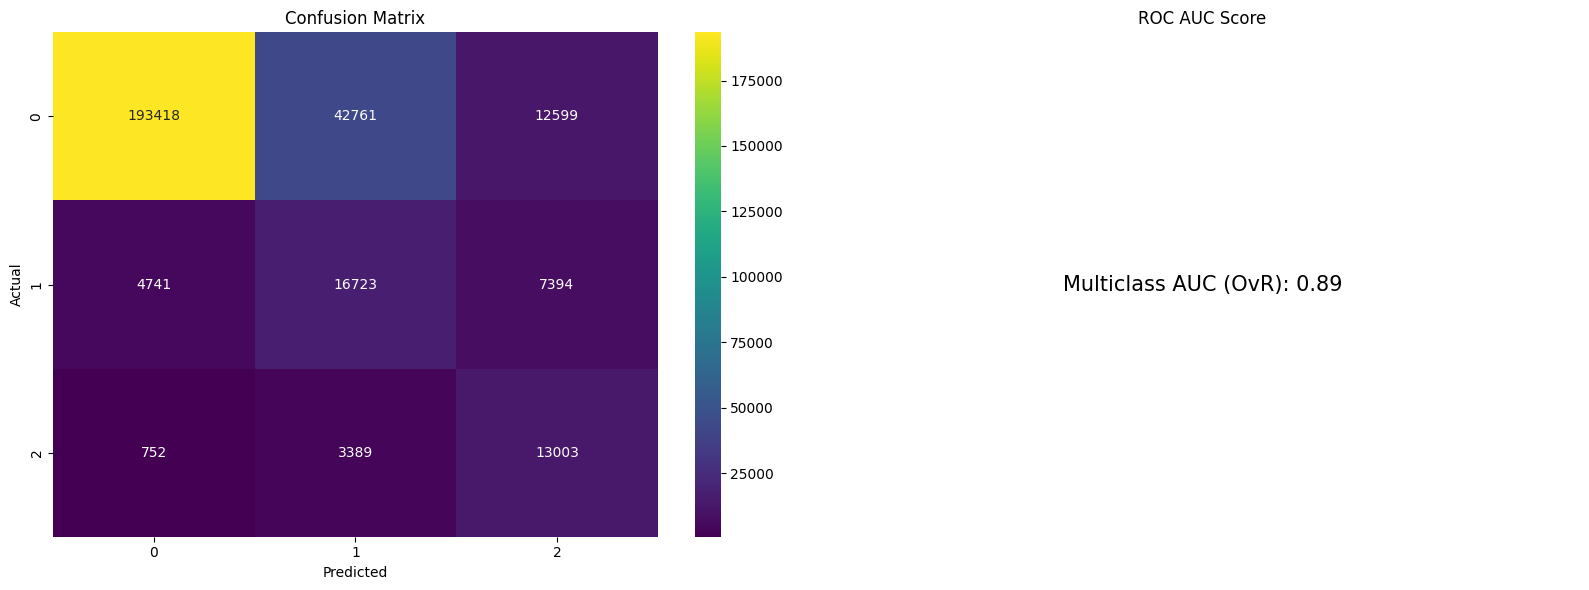


🚀 Starting Logistic Regression...
✅ Logistic Regression trained in 18.35s
--- LogisticRegression Evaluation ---
Accuracy:  0.7862
Precision: 0.5720 (Macro)
Recall:    0.7189 (Macro)
F1 Score:  0.6134 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.88    248778
           1       0.29      0.60      0.39     28858
           2       0.45      0.75      0.56     17144

    accuracy                           0.79    294780
   macro avg       0.57      0.72      0.61    294780
weighted avg       0.87      0.79      0.82    294780

------------------------------


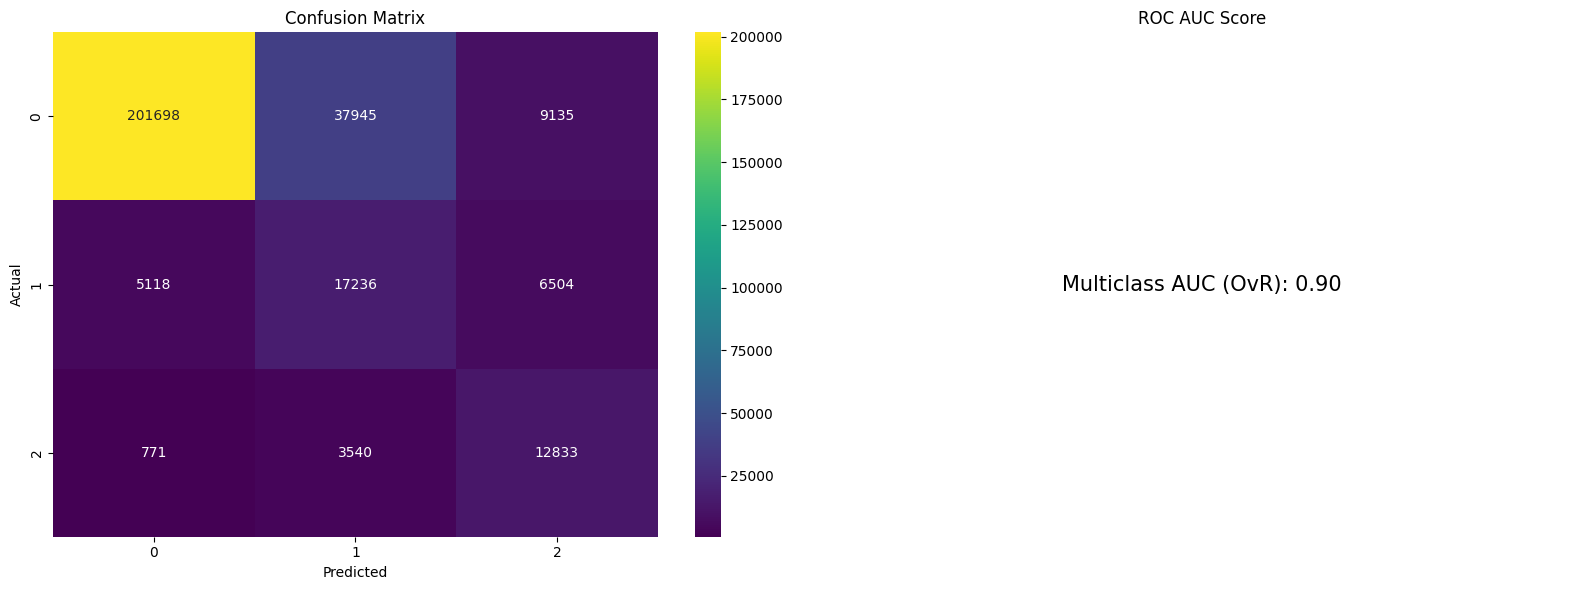


🚀 Starting LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.868905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1195587
[LightGBM] [Info] Number of data points in the train set: 120012, number of used features: 19843
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
✅ LightGBM trained in 171.67s
--- LGBMClassifier Evaluation ---
Accuracy:  0.7515
Precision: 0.5355 (Macro)
Recall:    0.6935 (Macro)
F1 Score:  0.5723 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.77      0.86    248778
           1       0.27      0.59      0.37     28858
           2       0.37      0.71      0.48     17144

    accuracy                           0.75    294780
   macro avg       0.54      0.69      0.57    294780
weighte

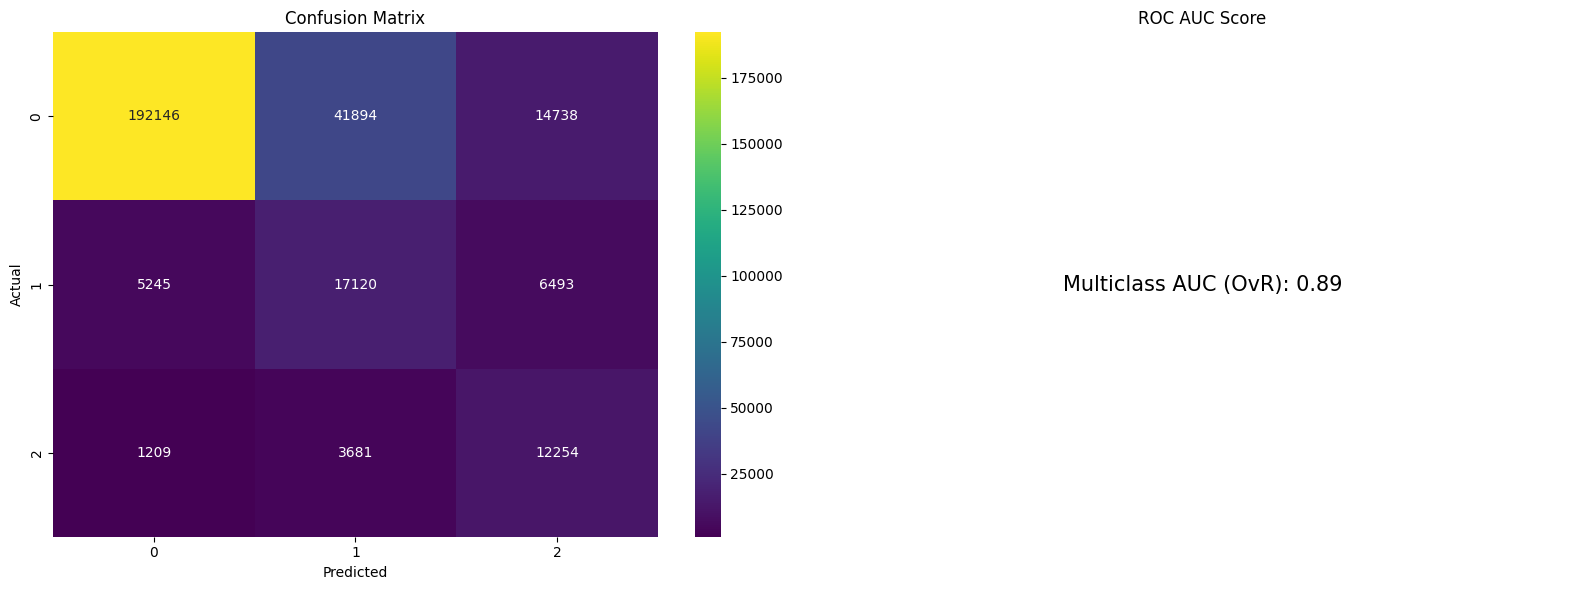


🚀 Starting XGBoost...
✅ XGBoost trained in 368.44s
--- XGBClassifier Evaluation ---
Accuracy:  0.7362
Precision: 0.5216 (Macro)
Recall:    0.6866 (Macro)
F1 Score:  0.5558 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.75      0.85    248778
           1       0.27      0.58      0.37     28858
           2       0.33      0.72      0.45     17144

    accuracy                           0.74    294780
   macro avg       0.52      0.69      0.56    294780
weighted avg       0.86      0.74      0.78    294780

------------------------------


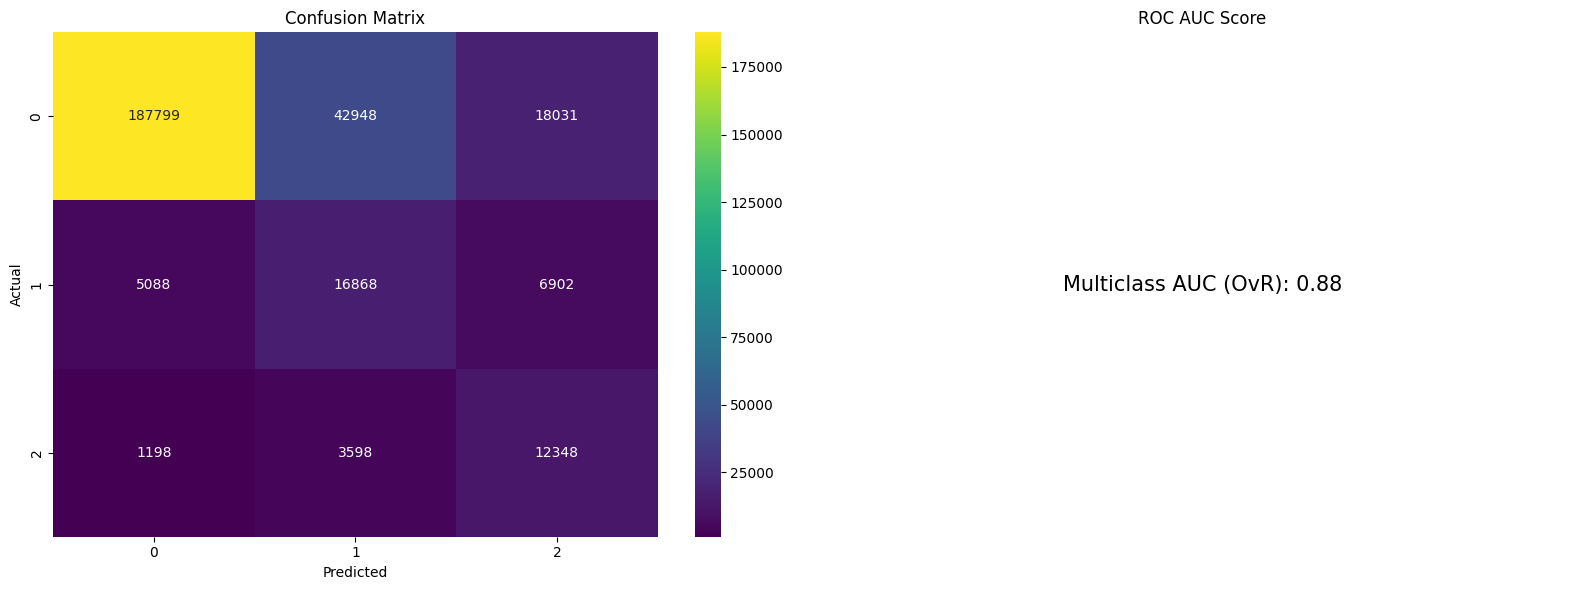


🚀 Starting Random Forest...
✅ Random Forest trained in 10.62s
--- RandomForestClassifier Evaluation ---
Accuracy:  0.7184
Precision: 0.4933 (Macro)
Recall:    0.6543 (Macro)
F1 Score:  0.5197 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.74      0.84    248778
           1       0.26      0.48      0.33     28858
           2       0.26      0.74      0.38     17144

    accuracy                           0.72    294780
   macro avg       0.49      0.65      0.52    294780
weighted avg       0.85      0.72      0.76    294780

------------------------------


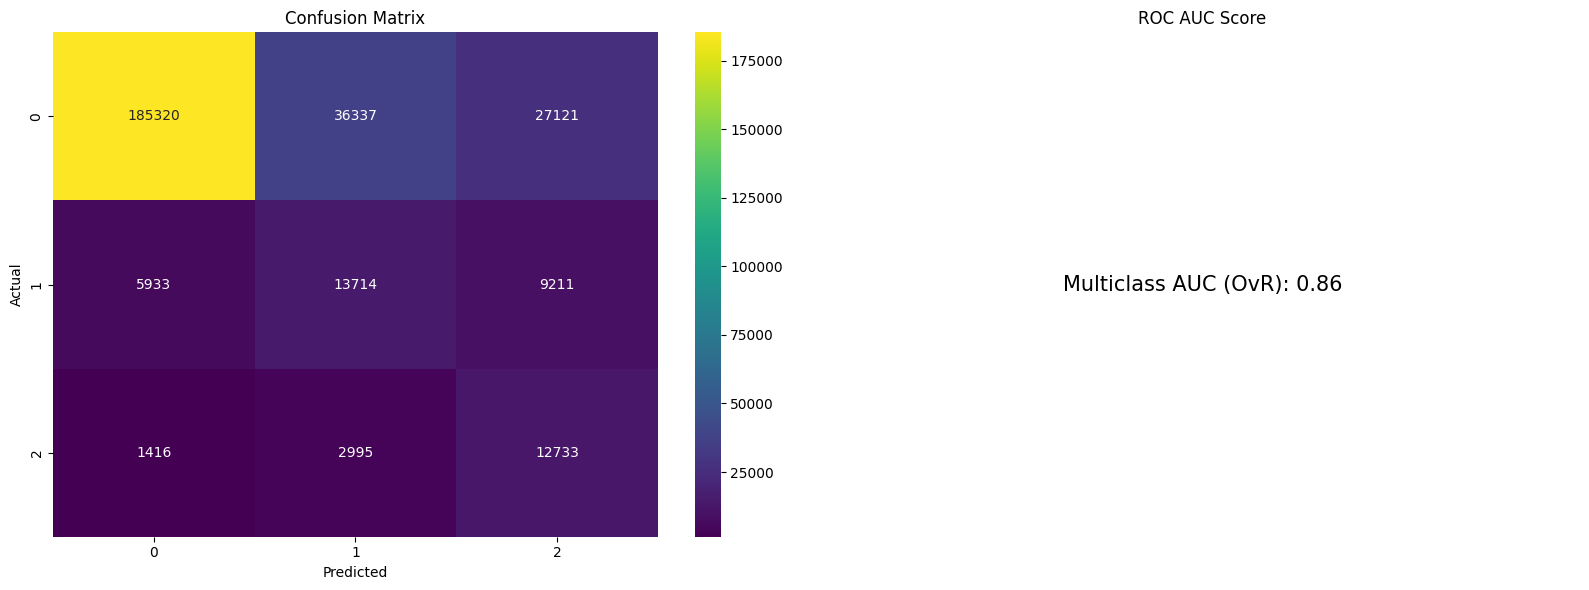


🚀 Starting CatBoost...
✅ CatBoost trained in 1194.81s
--- CatBoostClassifier Evaluation ---
Accuracy:  0.7636
Precision: 0.5434 (Macro)
Recall:    0.7006 (Macro)
F1 Score:  0.5829 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.79      0.87    248778
           1       0.28      0.58      0.38     28858
           2       0.38      0.74      0.50     17144

    accuracy                           0.76    294780
   macro avg       0.54      0.70      0.58    294780
weighted avg       0.87      0.76      0.80    294780

------------------------------


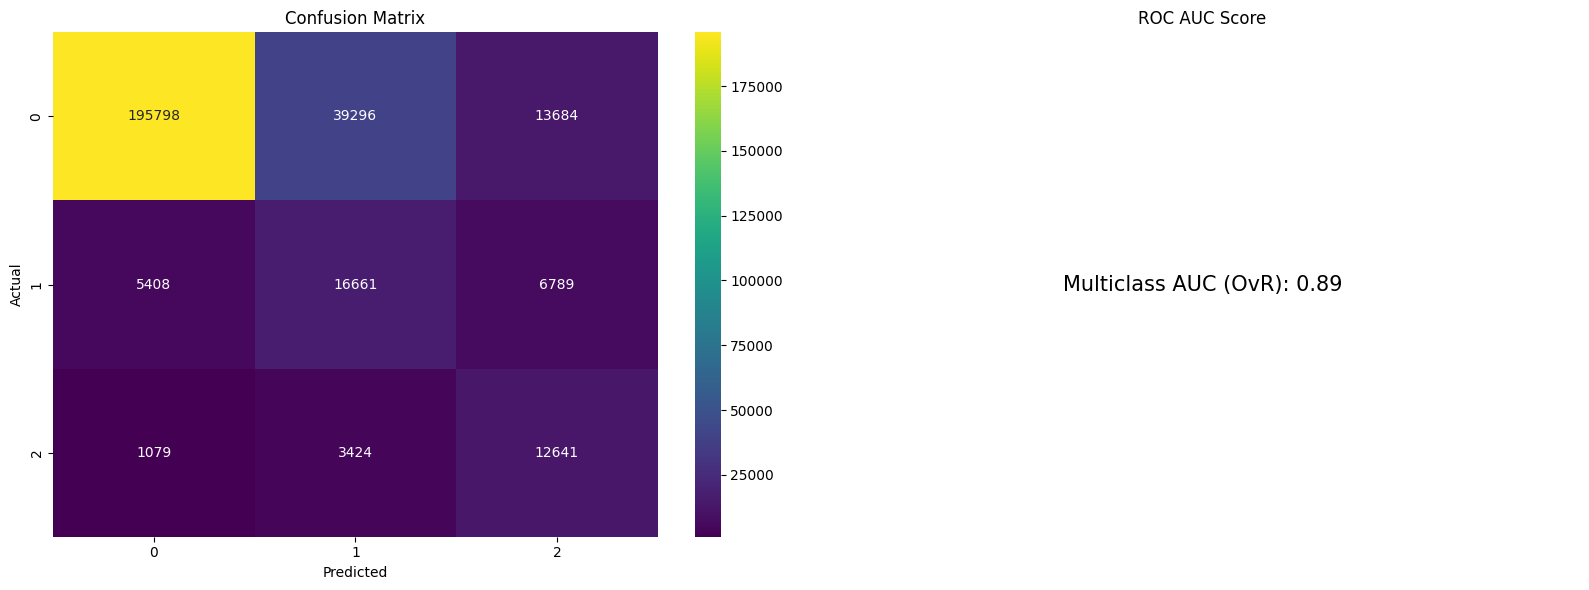

In [40]:

# Dictionary to store results
for name, model in models.items():
    print(f"\n🚀 Starting {name}...")
    
    # 1. Parallelization Check
    # Add n_jobs=-1 to models that support it to use your 8 cores
    if hasattr(model, 'n_jobs'):
        model.set_params(n_jobs=-1)
    
    start_time = time.time()
    
    try:
        # 2. Training
        model.fit(X_train_resampled, y_train_resampled)
        
        # 3. Evaluation (Using your custom function)
        print(f"✅ {name} trained in {time.time() - start_time:.2f}s")
        model_evaluation(model, X_test_tfidf, y_test)
        
    except Exception as e:
        print(f"❌ {name} failed: {e}")

# So here the clear winner is logistic regression

**Now lets do hyperameter tunning for this algo only**

In [41]:
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.1, 1, 10], # 0.1 for more smoothing, 10 for more detail
        'solver': ['lbfgs'], 
        'max_iter': [1000],
        'multi_class': ['multinomial'] # Better for 3-class problems
    },
    {
        'penalty': ['l1'],
        'C': [0.1, 1, 10],
        'solver': ['liblinear'], # Best for L1 penalty
        'max_iter': [1000]
    }
]

In [42]:
from sklearn.model_selection import GridSearchCV
LogisticRegression_model = LogisticRegression()
grid_search = GridSearchCV(
    estimator=LogisticRegression_model,
    param_grid=param_grid,
    scoring='f1_macro',  # Use macro F1 for imbalanced 
    n_jobs=-1,          # Use all CPU cores
    cv=3,               # 3-fold cross-validation
    verbose=2           # Show progress
)

In [43]:
grid_search.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10], 'max_iter': [1000],
                          'multi_class': ['multinomial'], 'penalty': ['l2'],
                          'solver': ['lbfgs']},
                         {'C': [0.1, 1, 10], 'max_iter': [1000],
                          'penalty': ['l1'], 'solver': ['liblinear']}],
             scoring='f1_macro', verbose=2)

--- LogisticRegression Evaluation ---
Accuracy:  0.7863
Precision: 0.5720 (Macro)
Recall:    0.7189 (Macro)
F1 Score:  0.6134 (Macro)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.88    248778
           1       0.29      0.60      0.39     28858
           2       0.45      0.75      0.56     17144

    accuracy                           0.79    294780
   macro avg       0.57      0.72      0.61    294780
weighted avg       0.87      0.79      0.82    294780

------------------------------


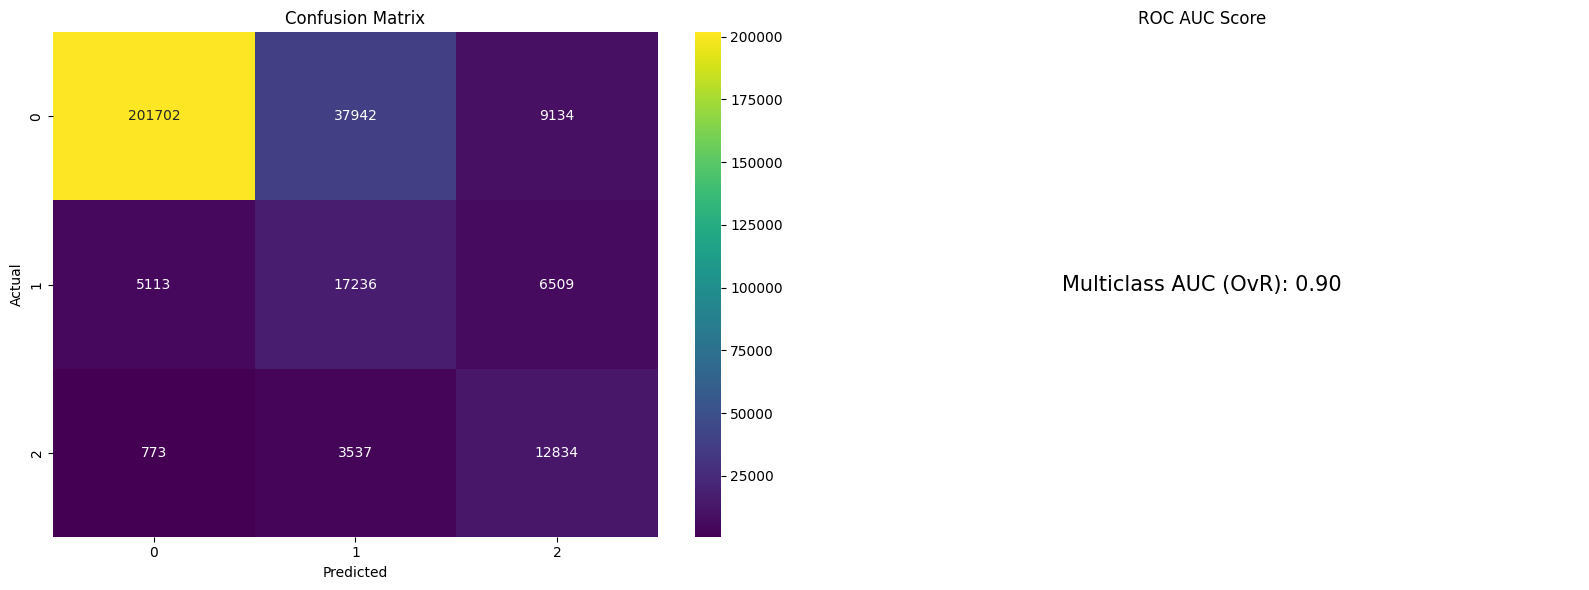

In [44]:
model_evaluation(grid_search.best_estimator_, X_test_tfidf, y_test)

# Best parameters are but the model did not change at all:

In [45]:
grid_search.best_params_

{'C': 1,
 'max_iter': 1000,
 'multi_class': 'multinomial',
 'penalty': 'l2',
 'solver': 'lbfgs'}

# Now lets save the model and preprocessor:

In [46]:
import joblib
model = models["Logistic Regression"]
with open("logistic_regression_model.joblib", "wb") as f:
    joblib.dump(model, f)

with open("vectorizer.joblib", "wb") as f:
    joblib.dump(vectorizer, f)

# Now loading the joblib file againg and predict the output

In [53]:
import os
import joblib
import sys
import subprocess

# Install gdown if not already installed
try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown"])
    import gdown

def download_file_from_google_drive(file_id, destination):
    if os.path.exists(destination):
        print(f"{destination} already exists. Skipping download.")
        return
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading {destination} from Google Drive using gdown...")
    gdown.download(url, destination, quiet=False)
    print(f"Downloaded {destination} successfully.")

# Download vectorizer.joblib if not present
download_file_from_google_drive("1Xjz353ARfeicN1MDJuR5y0frW7BuEjg8", "vectorizer.joblib")

with open("vectorizer.joblib", "rb") as f:
    loaded_vectorizer = joblib.load(f)
with open("logistic_regression_model.joblib", "rb") as f:
    loaded_model = joblib.load(f)

comments = [
    '''An extremely powerful story of a young Southern Negro, "
"from his late high school days through three years of college to his life in Harlem.
His early training prepared him for a life of humility before white men, 
but through injustices- large and small, he came to realize that he was an "invisible man".
People saw in him only a reflection of their preconceived ideas of what he was, denied his individuality, 
and ultimately did not see him at all. This theme, which has implications far beyond the obvious racial parallel, 
is skillfully handled. The incidents of the story are wholly absorbing. 
The boy's dismissal from college because of an innocent mistake,
his shocked reaction to the anonymity of the North and to Harlem, 
his nightmare experiences on a one-day job in a paint factory and in the hospital,
his lightning success as the Harlem leader of a communistic organization known as the Brotherhood,
his involvement in black versus white and black versus black clashes and his disillusion and understanding of his invisibility- 
all climax naturally in scenes of violence and riot, followed by a retreat which is both literal and figurative.'
'Parts of this experience may have been told before, but never with such freshness, intensity and power.'''
]
def get_wordnet_pos(tag):
    """Map POS tag to WordNet POS for lemmatization"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun if no match found

def preprocessing_the_text(text):
    cleaned_text = []
    for doc in text:
        if isinstance(doc, list):
            doc = " ".join([str(d).lower() for d in doc])
        elif isinstance(doc, str):
            doc = doc.lower()
        else:
            cleaned_text.append("")
            continue

        # Clean but keep punctuation for sent_tokenize
        doc = re.sub(r"[^a-zA-Z\s.,!?;:\-]", " ", doc)
        sentences = sent_tokenize(doc)
        
        processed_doc = []
        for sentence in sentences:
            # Tokenize and filter stops
            words = [w for w in word_tokenize(sentence) if w not in stop]
            
            lemmatized_sentence = []
            for w in words:
                tag = pos_tag([w])[0][1]
                wn_pos = get_wordnet_pos(tag)
                lemmatized_sentence.append(lemmatizer.lemmatize(w, wn_pos))
            
            processed_doc.append(" ".join(lemmatized_sentence))
        
        cleaned_text.append(" ".join(processed_doc))
    return cleaned_text

processed_comments = preprocessing_the_text(comments)
processed_comments_tfidf = loaded_vectorizer.transform(processed_comments)
predicted_sentiment = loaded_model.predict(processed_comments_tfidf)
sentiment_mapping = {0: "Positive", 1: "Neutral", 2: "Negative"}
predicted_sentiment_labels = [sentiment_mapping.get(pred, "Unknown") for pred in predicted_sentiment]

vectorizer.joblib already exists. Skipping download.


In [54]:
print(f"Predicted Sentiment: {predicted_sentiment_labels[0]}")

Predicted Sentiment: Positive
